# Brain Tumor MRI Classification

## Importing libraries

In [1]:
import os
import cv2 as cv
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from glob import glob
from datetime import datetime
from collections import Counter
from torchvision import transforms, models 
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                            confusion_matrix, auc, roc_auc_score,
                            precision_recall_curve, ConfusionMatrixDisplay, roc_curve)
from tqdm import tqdm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8')

In [2]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}') # Check the device

Using device: cuda


In [3]:
print(torch.__version__)
print(torch.version.cuda)

2.9.0+cu128
12.8


In [4]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

batch_size=16
image_size=(224, 224)
show_every = 50
epochs = 20

In [5]:
ROOT_DIR = '../data/'

data_list = []

for category in os.listdir(ROOT_DIR):
    category_path = os.path.join(ROOT_DIR, category)
    
    if not os.path.isdir(category_path):
        continue

    for data_class in os.listdir(category_path):
        class_path = os.path.join(category_path, data_class)
        
        if not os.path.isdir(class_path):
            continue

        count = 0
        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)
            
            if os.path.isfile(file_path) and file_name.lower().endswith('.jpg'):
                count += 1
        
        data_list.append({
            'category': category,
            'class': data_class,
            'count': count
        })

df = pd.DataFrame(data_list)
pivot_df = df.pivot_table(index='class', columns='category', values='count', fill_value=0)

In [6]:
pivot_df

category,Testing,Training,Validating
class,,,
glioma_tumor,100.0,661.0,165.0
meningioma_tumor,115.0,658.0,164.0
no_tumor,105.0,316.0,79.0
pituitary_tumor,74.0,662.0,165.0


In [7]:
def plot_class_counts(pivot_df, category_names=['Training', 'Testing']):
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    plot_data = pivot_df.stack().reset_index(name='Count')
    plot_data.columns = ['Class', 'Category', 'Count']

    sns.barplot(
        x='Class', 
        y='Count', 
        hue='Category', 
        data=plot_data, 
        palette='Set1', 
        ax=ax
    )
    
    ax.set_title('Distribution of Training and Test set', fontsize=14, weight='bold')
    ax.set_xlabel('Classes', fontsize=12)
    ax.set_ylabel('Counts', fontsize=12)
    
    plt.xticks(rotation=45, ha='right')
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 5), 
                    textcoords='offset points')
        
    plt.legend(title='Datasets')
    plt.tight_layout()
    plt.show()

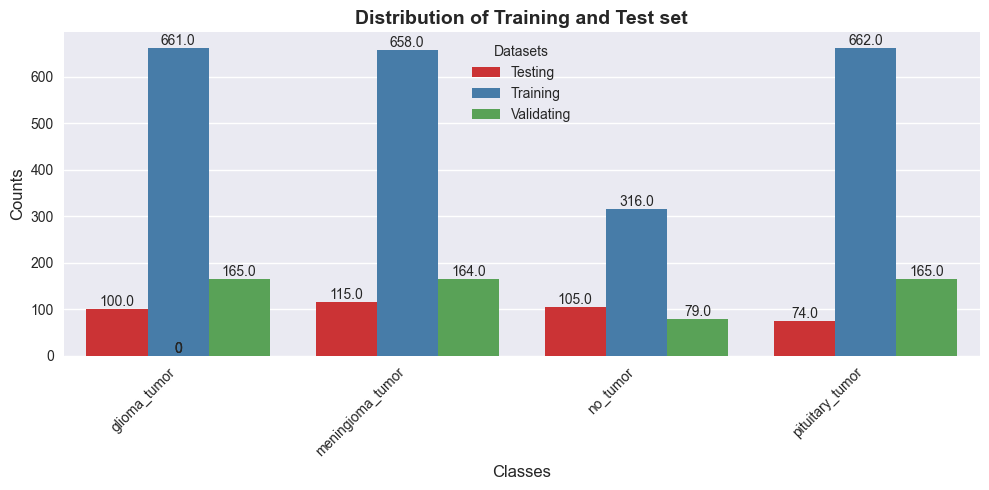

In [8]:
plot_class_counts(pivot_df)

In [9]:
root_dir = "../data/Training"
val_dir = "../data/Validating"
split_ratio = 0.2

if os.path.exists(val_dir) and any(os.listdir(val_dir)):
    print("Validation folder already exists and is not empty. Skipping split.")
else:
    os.makedirs(val_dir, exist_ok=True)
    print("Splitting data into Training and Validating sets...")

    for cls in os.listdir(root_dir):
        cls_train = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_train):
            continue

        cls_val = os.path.join(val_dir, cls)
        os.makedirs(cls_val, exist_ok=True)
        
        files = glob(os.path.join(cls_train, "*.jpg"))
        if not files:
            continue

        random.shuffle(files)
        n_val = int(len(files) * split_ratio)

        if len(os.listdir(cls_val)) == 0:
            for f in files[:n_val]:
                shutil.move(f, cls_val)
            print(f"{cls}: moved {n_val}/{len(files)} images to validation.")
        else:
            print(f"{cls}: validation folder already contains files, skipping.")
    
    print("Data split completed successfully.")

Validation folder already exists and is not empty. Skipping split.


In [10]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomRotation(degrees=(-10, 10)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(3, 3))
    ], p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(image_size),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(image_size),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

training_dataset = ImageFolder(os.path.join(ROOT_DIR, 'Training'), transform=train_transform)
test_dataset = ImageFolder(os.path.join(ROOT_DIR, 'Testing'), transform=test_transform)
val_dataset = ImageFolder(os.path.join(ROOT_DIR, 'Validating'), transform=val_transform)

In [11]:
training_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [12]:
train_targets = training_dataset.targets
train_counts = Counter(train_targets)
class_names = training_dataset.classes

class_weights = torch.tensor(
    [1.0 / train_counts[i] for i in range(len(class_names))],
    dtype=torch.float
).to(device)

class_weights

tensor([0.0015, 0.0015, 0.0032, 0.0015], device='cuda:0')

In [13]:
classes = training_dataset.classes
print(classes)

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [14]:
images, labels = next(iter(test_loader))
print(f'Images shape: {images.shape}')
print(f'Labels shape: {labels.shape}')

Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])


In [15]:
def im_convert(tensor):
    if tensor.dim() == 4:
        tensor = tensor.squeeze(0)
        
    image = tensor.clone().cpu().detach().numpy()
    image = image.transpose(1, 2, 0)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * mean + std # Denormalization
    
    image = image.clip(0, 1)
    return image

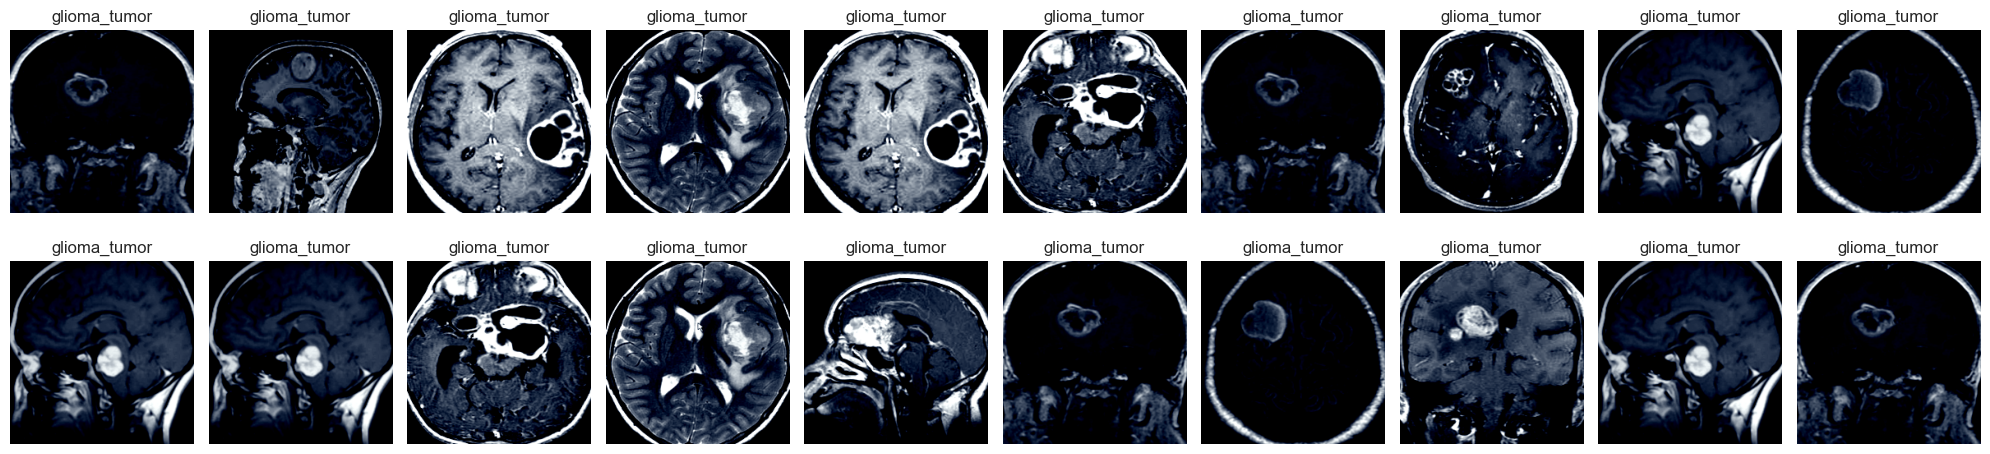

In [16]:
fig = plt.figure(figsize=(20, 5))
for i in range(20):
    idx = np.random.randint(1, len(labels))
    ax = fig.add_subplot(2, 10, i+1, xticks=[], yticks=[])
    plt.imshow(im_convert(images[idx]), cmap='gray')
    ax.set_title(classes[labels[idx]])
plt.tight_layout()
plt.show()

In [17]:
# Load EfficientNet-B0 with ImageNet pre-trained weights
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).to(device)

# Set requires_grad = False because weights must not change!
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-6:].parameters():
    param.requires_grad = True

# Change the last lyaer of classifier
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.SiLU(),
    nn.Dropout(p=0.5),
    nn.Linear(512, 256),
    nn.SiLU(),
    nn.Dropout(p=0.5),
    nn.Linear(256, 4)
  ).to(device)

In [18]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-4,
    steps_per_epoch=len(training_loader),
    epochs=epochs
)

In [19]:
def get_metrics(labels_combined, preds_combined, probs_combined, loss_avg, num_classes=4):
    labels_combined = labels_combined.astype(int)
    preds_combined = preds_combined.astype(int)

    prfs = precision_recall_fscore_support(labels_combined, preds_combined, average='macro', zero_division=0)

    macro_precision = prfs[0]
    macro_recall = prfs[1]
    macro_f1 = prfs[2]
    
    accuracy = (labels_combined == preds_combined).mean()

    conf_matrix = confusion_matrix(labels_combined, preds_combined)
    macro_specificity = 0.0

    for i in range(num_classes):
        TN = conf_matrix.sum() - conf_matrix[i, :].sum() - conf_matrix[:, i].sum() + conf_matrix[i, i]
        FP = conf_matrix[:, i].sum() - conf_matrix[i, i]

        specificity_i = TN / (TN + FP) if (TN + FP) != 0 else 0.0
        macro_specificity += specificity_i

    macro_specificity /= num_classes

    macro_auc = np.nan
    if probs_combined is not None and len(np.unique(labels_combined)) > 1:
         macro_auc = roc_auc_score(labels_combined, probs_combined, multi_class='ovr', average='macro')
    
    return {
        'Loss': loss_avg,
        'Accuracy': accuracy,
        'Precision': macro_precision,
        'Recall': macro_recall,
        'F1': macro_f1,
        'Specificity': macro_specificity,
        'AUC': macro_auc
    }

In [20]:
def train_model(training_loader, model, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_corrects = 0
    total_predes = 0
    samples_processed = 0

    all_labels = []
    all_preds = []
    for batch_number, (images, labels) in enumerate(training_loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)

        # Accuracy
        _, preds = torch.max(outputs, dim=1)
        total_corrects += (preds == labels).sum().item()

        samples_processed += batch_size

        # Backwarad pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Updating learning rate
        scheduler.step()

        all_labels.append(labels.cpu().detach().numpy())
        all_preds.append(preds.cpu().detach().numpy())

        if (batch_number + 1) % show_every == 0:
            samples_processed += images.size(0)
            current_loss = total_loss / samples_processed
            current_acc = total_corrects / samples_processed
            print(f"Batch {batch_number + 1}/{len(training_loader)}, "
                  f"Cumulative Loss: {current_loss:0.4f}, "
                  f"Cumulative Accuracy: {current_acc * 100:.2f}%")

    total_samples = len(training_loader.dataset)
    avg_loss = total_loss / total_samples
    avg_accuracy = total_corrects / total_samples

    labels_combined = np.concatenate(all_labels)
    preds_combined = np.concatenate(all_preds)
    
    return get_metrics(labels_combined, preds_combined, None, avg_loss)

In [21]:
def eval_model(val_loader, model, criterion, device, num_classes=4):
    model.eval()

    total_loss = 0.0
    total_corrects = 0
    samples_processed = 0

    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for batch_number, (images, labels) in enumerate(val_loader):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)

            # Accuracy
            _, preds = torch.max(outputs, dim=1)
            probs = F.softmax(outputs, dim=1)
            total_corrects += (preds == labels).sum().item()

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    avg_accuracy = total_corrects / len(val_loader.dataset)

    labels_combined = np.concatenate(all_labels)
    preds_combined = np.concatenate(all_preds)
    probs_combined = np.concatenate(all_probs)

    metrics = get_metrics(labels_combined, preds_combined, probs_combined, avg_loss)
    
    metrics['labels_raw'] = labels_combined
    metrics['probs_raw'] = probs_combined
    
    return metrics

In [22]:
# Training loop
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epoch_history_df = pd.DataFrame(columns=[
    'Epoch', 'Phase', 'Loss', 'Accuracy', 'Precision', 'Recall', 'F1', 'Specificity', 'AUC', 'PR_AUC'
])

best_loss = float('inf')
tolerance = 0

current_datetime = datetime.now().time().strftime("%H:%M:%S")
start = datetime.now()
print(f'Started at: {current_datetime}')

for epoch in range(epochs):
    print(f"\n--- Epoch {epoch + 1}/{epochs} ---")
    
    train_metrics = train_model(training_loader, model, criterion, optimizer, device)
    val_metrics = eval_model(val_loader, model, criterion, device, num_classes=len(classes)) 

    pr_auc_scores = []
    for i, _ in enumerate(classes):
        precision_points, recall_points, _ = precision_recall_curve(
            (val_metrics['labels_raw'] == i).astype(int), val_metrics['probs_raw'][:, i]
        )
        pr_auc_scores.append(auc(recall_points, precision_points))
        
    macro_pr_auc = np.mean(pr_auc_scores)
    
    train_record = {'Epoch': epoch + 1, 'Phase': 'Train', 'PR_AUC': np.nan}
    train_record.update(train_metrics)
    
    val_record = {'Epoch': epoch + 1, 'Phase': 'Validation', 'PR_AUC': macro_pr_auc}
    val_record.update(val_metrics)
    
    epoch_history_df = pd.concat([epoch_history_df, pd.DataFrame([train_record, val_record])], ignore_index=True)

    eval_loss = val_metrics['Loss']
    if eval_loss < best_loss:
        best_loss = eval_loss

        save_path = "best_model_weights.pth"
        torch.save(model.state_dict(), save_path) 
        print(f"✅ Validation Loss improved. Saving best model to '{save_path}'")
        tolerance = 0
    else:
        tolerance += 1
        if tolerance >= 5:
            print("Early stopping triggered.")
            break

    print(f"\nTrain Acc: {train_metrics['Accuracy'] * 100:.2f}% | Train Loss: {train_metrics['Loss']:.4f}")
    print(f"Val Acc: {val_metrics['Accuracy'] * 100:.2f}% | Val Loss: {val_metrics['Loss']:.4f}")
    print(f"Val P/R/F1: {val_metrics['Precision']:.4f}/{val_metrics['Recall']:.4f}/{val_metrics['F1']:.4f} | Val AUC/PR_AUC: {val_metrics['AUC']:.4f}/{macro_pr_auc:.4f}")
    print("-" * 70)

end = datetime.now()
duration = end - start
print(f"\nIt takes: {duration}")

Started at: 19:14:11

--- Epoch 1/20 ---
Batch 50/144, Cumulative Loss: 1.3597, Cumulative Accuracy: 22.79%
Batch 100/144, Cumulative Loss: 1.3585, Cumulative Accuracy: 24.20%
✅ Validation Loss improved. Saving best model to 'best_model_weights.pth'

Train Acc: 26.25% | Train Loss: 1.3836
Val Acc: 40.84% | Val Loss: 21.8454
Val P/R/F1: 0.6580/0.4372/0.3396 | Val AUC/PR_AUC: 0.8226/0.6254
----------------------------------------------------------------------

--- Epoch 2/20 ---
Batch 50/144, Cumulative Loss: 1.3460, Cumulative Accuracy: 35.29%
Batch 100/144, Cumulative Loss: 1.3365, Cumulative Accuracy: 42.10%
✅ Validation Loss improved. Saving best model to 'best_model_weights.pth'

Train Acc: 47.63% | Train Loss: 1.3519
Val Acc: 79.41% | Val Loss: 19.8989
Val P/R/F1: 0.7905/0.7910/0.7898 | Val AUC/PR_AUC: 0.9447/0.8637
----------------------------------------------------------------------

--- Epoch 3/20 ---
Batch 50/144, Cumulative Loss: 1.2006, Cumulative Accuracy: 65.07%
Batch 100/

In [23]:
epoch_history_df

,Epoch,Phase,Loss,Accuracy,Precision,Recall,F1,Specificity,AUC,PR_AUC,labels_raw,probs_raw
0,1,Train,1.383644,0.262516,0.277343,0.267101,0.190774,0.755787,NaN,NaN,NaN,NaN
1,1,Validation,21.845395,0.408377,0.658042,0.437164,0.339611,0.796130,0.822639,0.625412,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[0.2481361, 0.24721773, 0.24931665, 0.2553295..."
2,2,Train,1.351930,0.476273,0.501692,0.481119,0.450426,0.823272,NaN,NaN,NaN,NaN
3,2,Validation,19.898943,0.794066,0.790543,0.791015,0.789780,0.929787,0.944654,0.863684,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[0.31006718, 0.2541488, 0.2193731, 0.21641093..."
4,3,Train,0.973424,0.706138,0.694902,0.717420,0.701215,0.901337,NaN,NaN,NaN,NaN
5,3,Validation,5.920794,0.869110,0.863915,0.882741,0.871475,0.955901,0.973264,0.926155,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[0.9759571, 0.017757498, 0.004356765, 0.00192..."
6,4,Train,0.558616,0.784066,0.774959,0.795558,0.782070,0.927438,NaN,NaN,NaN,NaN
7,4,Validation,4.496634,0.886562,0.889091,0.897764,0.888176,0.961253,0.988113,0.970203,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[0.9663645, 0.016645607, 0.009119922, 0.00786..."
8,5,Train,0.467668,0.827601,0.817480,0.834289,0.824043,0.942177,NaN,NaN,NaN,NaN
9,5,Validation,3.143860,0.928447,0.935331,0.932801,0.933874,0.975124,0.993215,0.984098,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[0.9990651, 0.00060210633, 0.00022638247, 0.0..."


In [24]:
model.load_state_dict(torch.load('best_model_weights.pth', map_location=device))
model.eval()

test_labels = []
test_preds = []
test_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        probs = F.softmax(outputs, dim=1)

        test_labels.append(labels.cpu().detach().numpy())
        test_preds.append(preds.cpu().detach().numpy())
        test_probs.append(probs.cpu().detach().numpy())

test_labels = np.concatenate(test_labels)
test_preds = np.concatenate(test_preds)
test_probs = np.concatenate(test_probs)

test_metrics = get_metrics(test_labels, test_preds, test_probs, 0.0, num_classes=4)

print("\n--- Test Results ---")
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")


--- Test Results ---
Loss: 0.0000
Accuracy: 0.7995
Precision: 0.8594
Recall: 0.7873
F1: 0.7829
Specificity: 0.9302
AUC: 0.9543


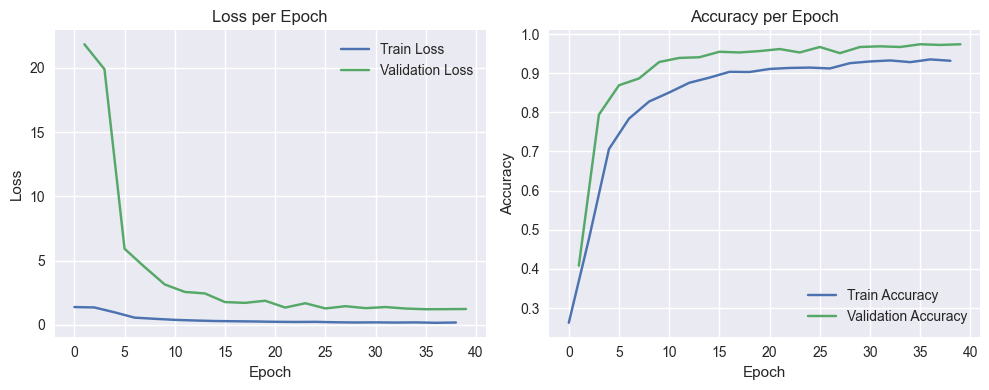

In [25]:
# --- Visualization: Loss & Accuracy Curves ---
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epoch_history_df[epoch_history_df['Phase']=='Train']['Loss'], label='Train Loss')
plt.plot(epoch_history_df[epoch_history_df['Phase']=='Validation']['Loss'], label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epoch_history_df[epoch_history_df['Phase']=='Train']['Accuracy'], label='Train Accuracy')
plt.plot(epoch_history_df[epoch_history_df['Phase']=='Validation']['Accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


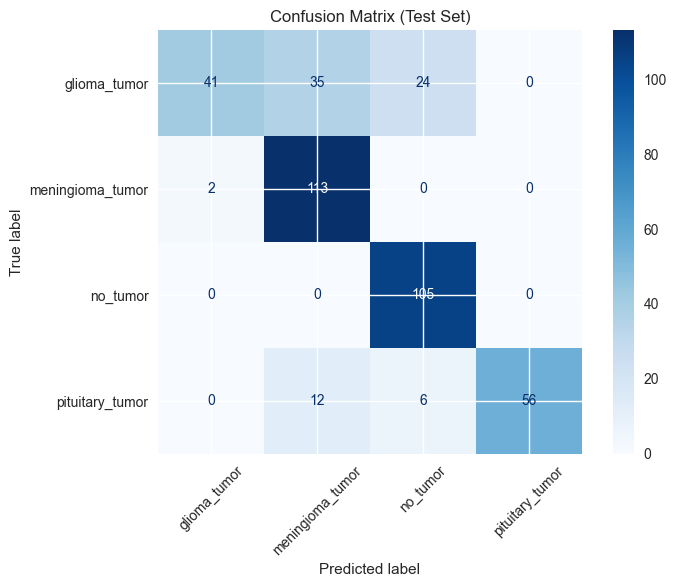

In [26]:
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (Test Set)")
plt.show()

In [34]:
print(cm)

[[ 41  35  24   0]
 [  2 113   0   0]
 [  0   0 105   0]
 [  0  12   6  56]]


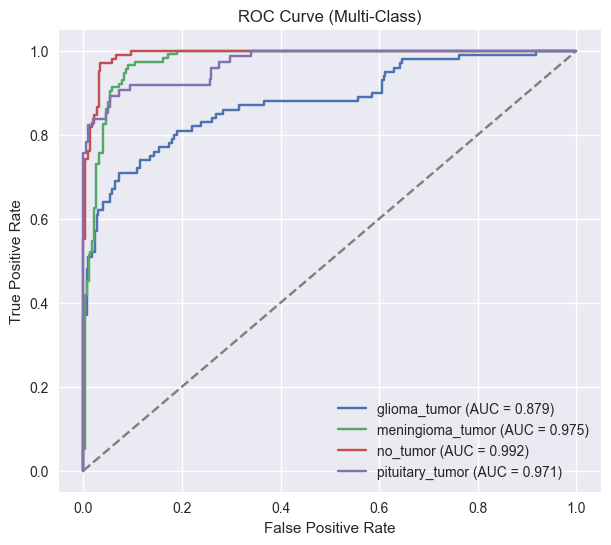

In [27]:
# --- ROC Curve ---
plt.figure(figsize=(7,6))
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve((test_labels == i).astype(int), test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend()
plt.show()

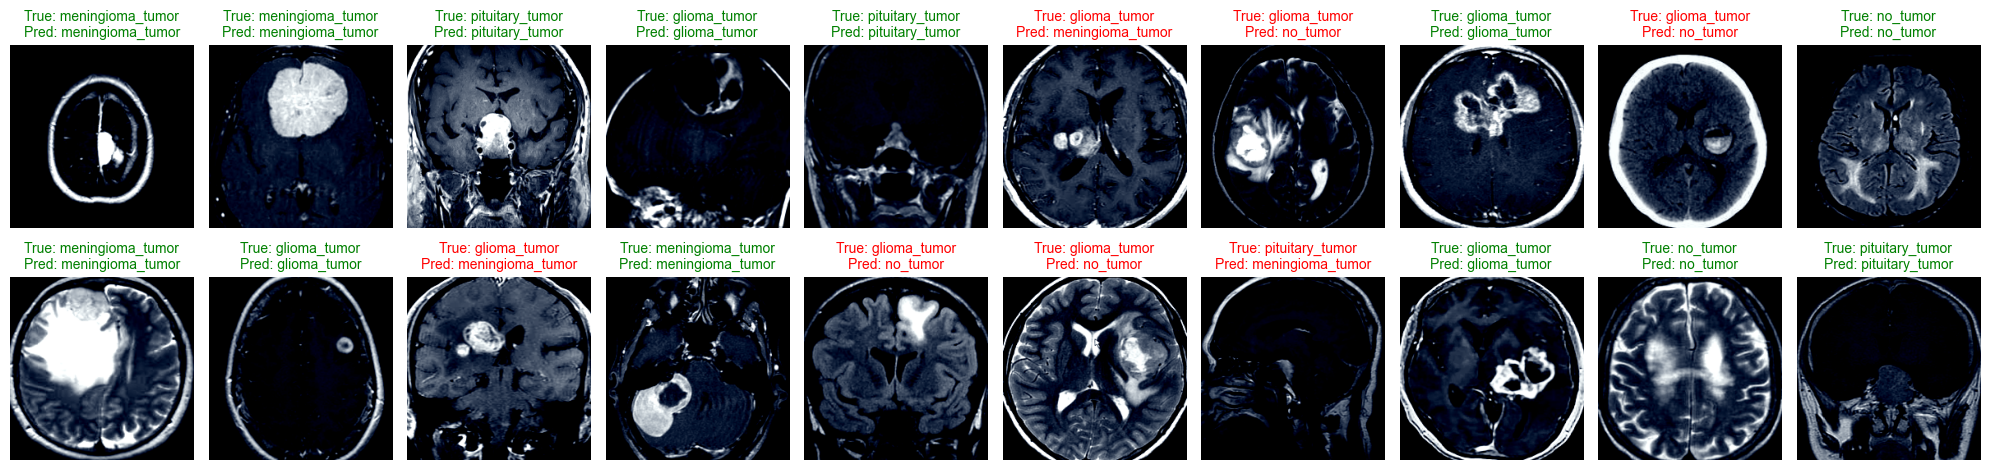

In [28]:
# Get some random images and predict the lables
random_indices = np.random.choice(len(test_dataset), size=20)

model.eval()

plt.figure(figsize=(20, 5))

with torch.no_grad():
    for i, idx in enumerate(random_indices):
        images, labels = test_dataset[idx]
        images = images.unsqueeze(0).to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)

        true_labels = classes[labels]
        pred_labels = classes[preds.item()]

        is_correct = (true_labels == pred_labels)
        color = "green" if is_correct else "red"

        title = f"True: {true_labels}\nPred: {pred_labels}"

        plt.subplot(2, 10, i+1)
        plt.imshow(im_convert(images))
        plt.title(title, color=color, fontsize=10)
        plt.axis('off')
    plt.tight_layout() 
    plt.show()

In [29]:
def visualize_gradcam(model, image_path, target_layers, class_names, device):
    """
    Generate and visualize Grad-CAM heatmap for a given MRI image.

    Args:
        model: trained PyTorch model
        image_path: path to MRI image
        target_layers: target layer(s) for Grad-CAM (e.g., model.features[-1])
        class_names: list of class labels ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
        device: 'cuda' or 'cpu'
    """

    model.eval()

    # Read and preprocess image
    rgb_img = cv.imread(image_path, cv.IMREAD_COLOR)
    if rgb_img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    rgb_img = cv.cvtColor(rgb_img, cv.COLOR_BGR2RGB)
    rgb_img = cv.resize(rgb_img, (224, 224))
    rgb_img_float = np.float32(rgb_img) / 255.0

    input_tensor = preprocess_image(
        rgb_img_float,
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ).to(device)

    cam = GradCAM(model=model, target_layers=target_layers)

    with torch.no_grad():
        output = model(input_tensor)
        pred_class = output.argmax(dim=1).item()
        pred_name = class_names[pred_class]
        print(f"🧠 Predicted class: {pred_name}")

    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_class)])
    grayscale_cam = grayscale_cam[0, :]
    visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(5, 5))
    plt.imshow(visualization)
    plt.title(f"Grad-CAM Visualization → {pred_name.upper()}")
    plt.axis('off')
    plt.show()


🧠 Predicted class: pituitary_tumor


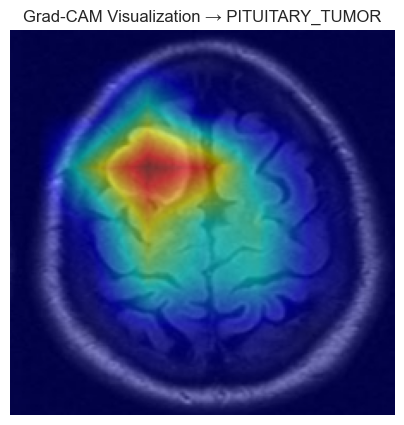

In [33]:
# Define target layer — the last convolutional block of EfficientNet
target_layers = [model.features[-1]]

# Class names (in same order as your dataset folders)
class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

# Example usage:
image_path = "../data/Testing/glioma_tumor/image(100).jpg"
visualize_gradcam(model, image_path, target_layers, class_names, device)


In [31]:
def visualize_gradcam_grid(model, dataset_root, class_names, target_layers, device, samples_per_class=2):
    """
    Generate Grad-CAM visualizations for multiple classes and show them in a grid.

    Args:
        model: trained PyTorch model
        dataset_root: path to dataset folder (e.g. './data/Testing')
        class_names: list of class names (folder names)
        target_layers: layers for GradCAM (e.g. [model.features[-1]])
        device: 'cuda' or 'cpu'
        samples_per_class: how many random samples to visualize per class
    """

    model.eval()
    cam = GradCAM(model=model, target_layers=target_layers)

    fig, axs = plt.subplots(len(class_names), samples_per_class, figsize=(5 * samples_per_class, 5 * len(class_names)))

    for i, cls_name in enumerate(class_names):
        class_path = os.path.join(dataset_root, cls_name)
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if len(image_files) == 0:
            print(f"⚠️ No images found for class: {cls_name}")
            continue

        sampled_images = random.sample(image_files, min(samples_per_class, len(image_files)))

        for j, img_file in enumerate(sampled_images):
            img_path = os.path.join(class_path, img_file)
            rgb_img = cv.imread(img_path, cv.IMREAD_COLOR)
            rgb_img = cv.cvtColor(rgb_img, cv.COLOR_BGR2RGB)
            rgb_img = cv.resize(rgb_img, (224, 224))
            rgb_img_float = np.float32(rgb_img) / 255.0

            input_tensor = preprocess_image(
                rgb_img_float,
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ).to(device)

            with torch.no_grad():
                output = model(input_tensor)
                pred_class = output.argmax(dim=1).item()
                pred_name = class_names[pred_class]

            grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_class)])
            grayscale_cam = grayscale_cam[0, :]
            visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

            ax = axs[i, j] if len(class_names) > 1 else axs[j]
            ax.imshow(visualization)
            ax.set_title(f"{cls_name}\nPred: {pred_name}", fontsize=12, fontweight='bold')
            ax.axis('off')

    plt.tight_layout()
    plt.show()


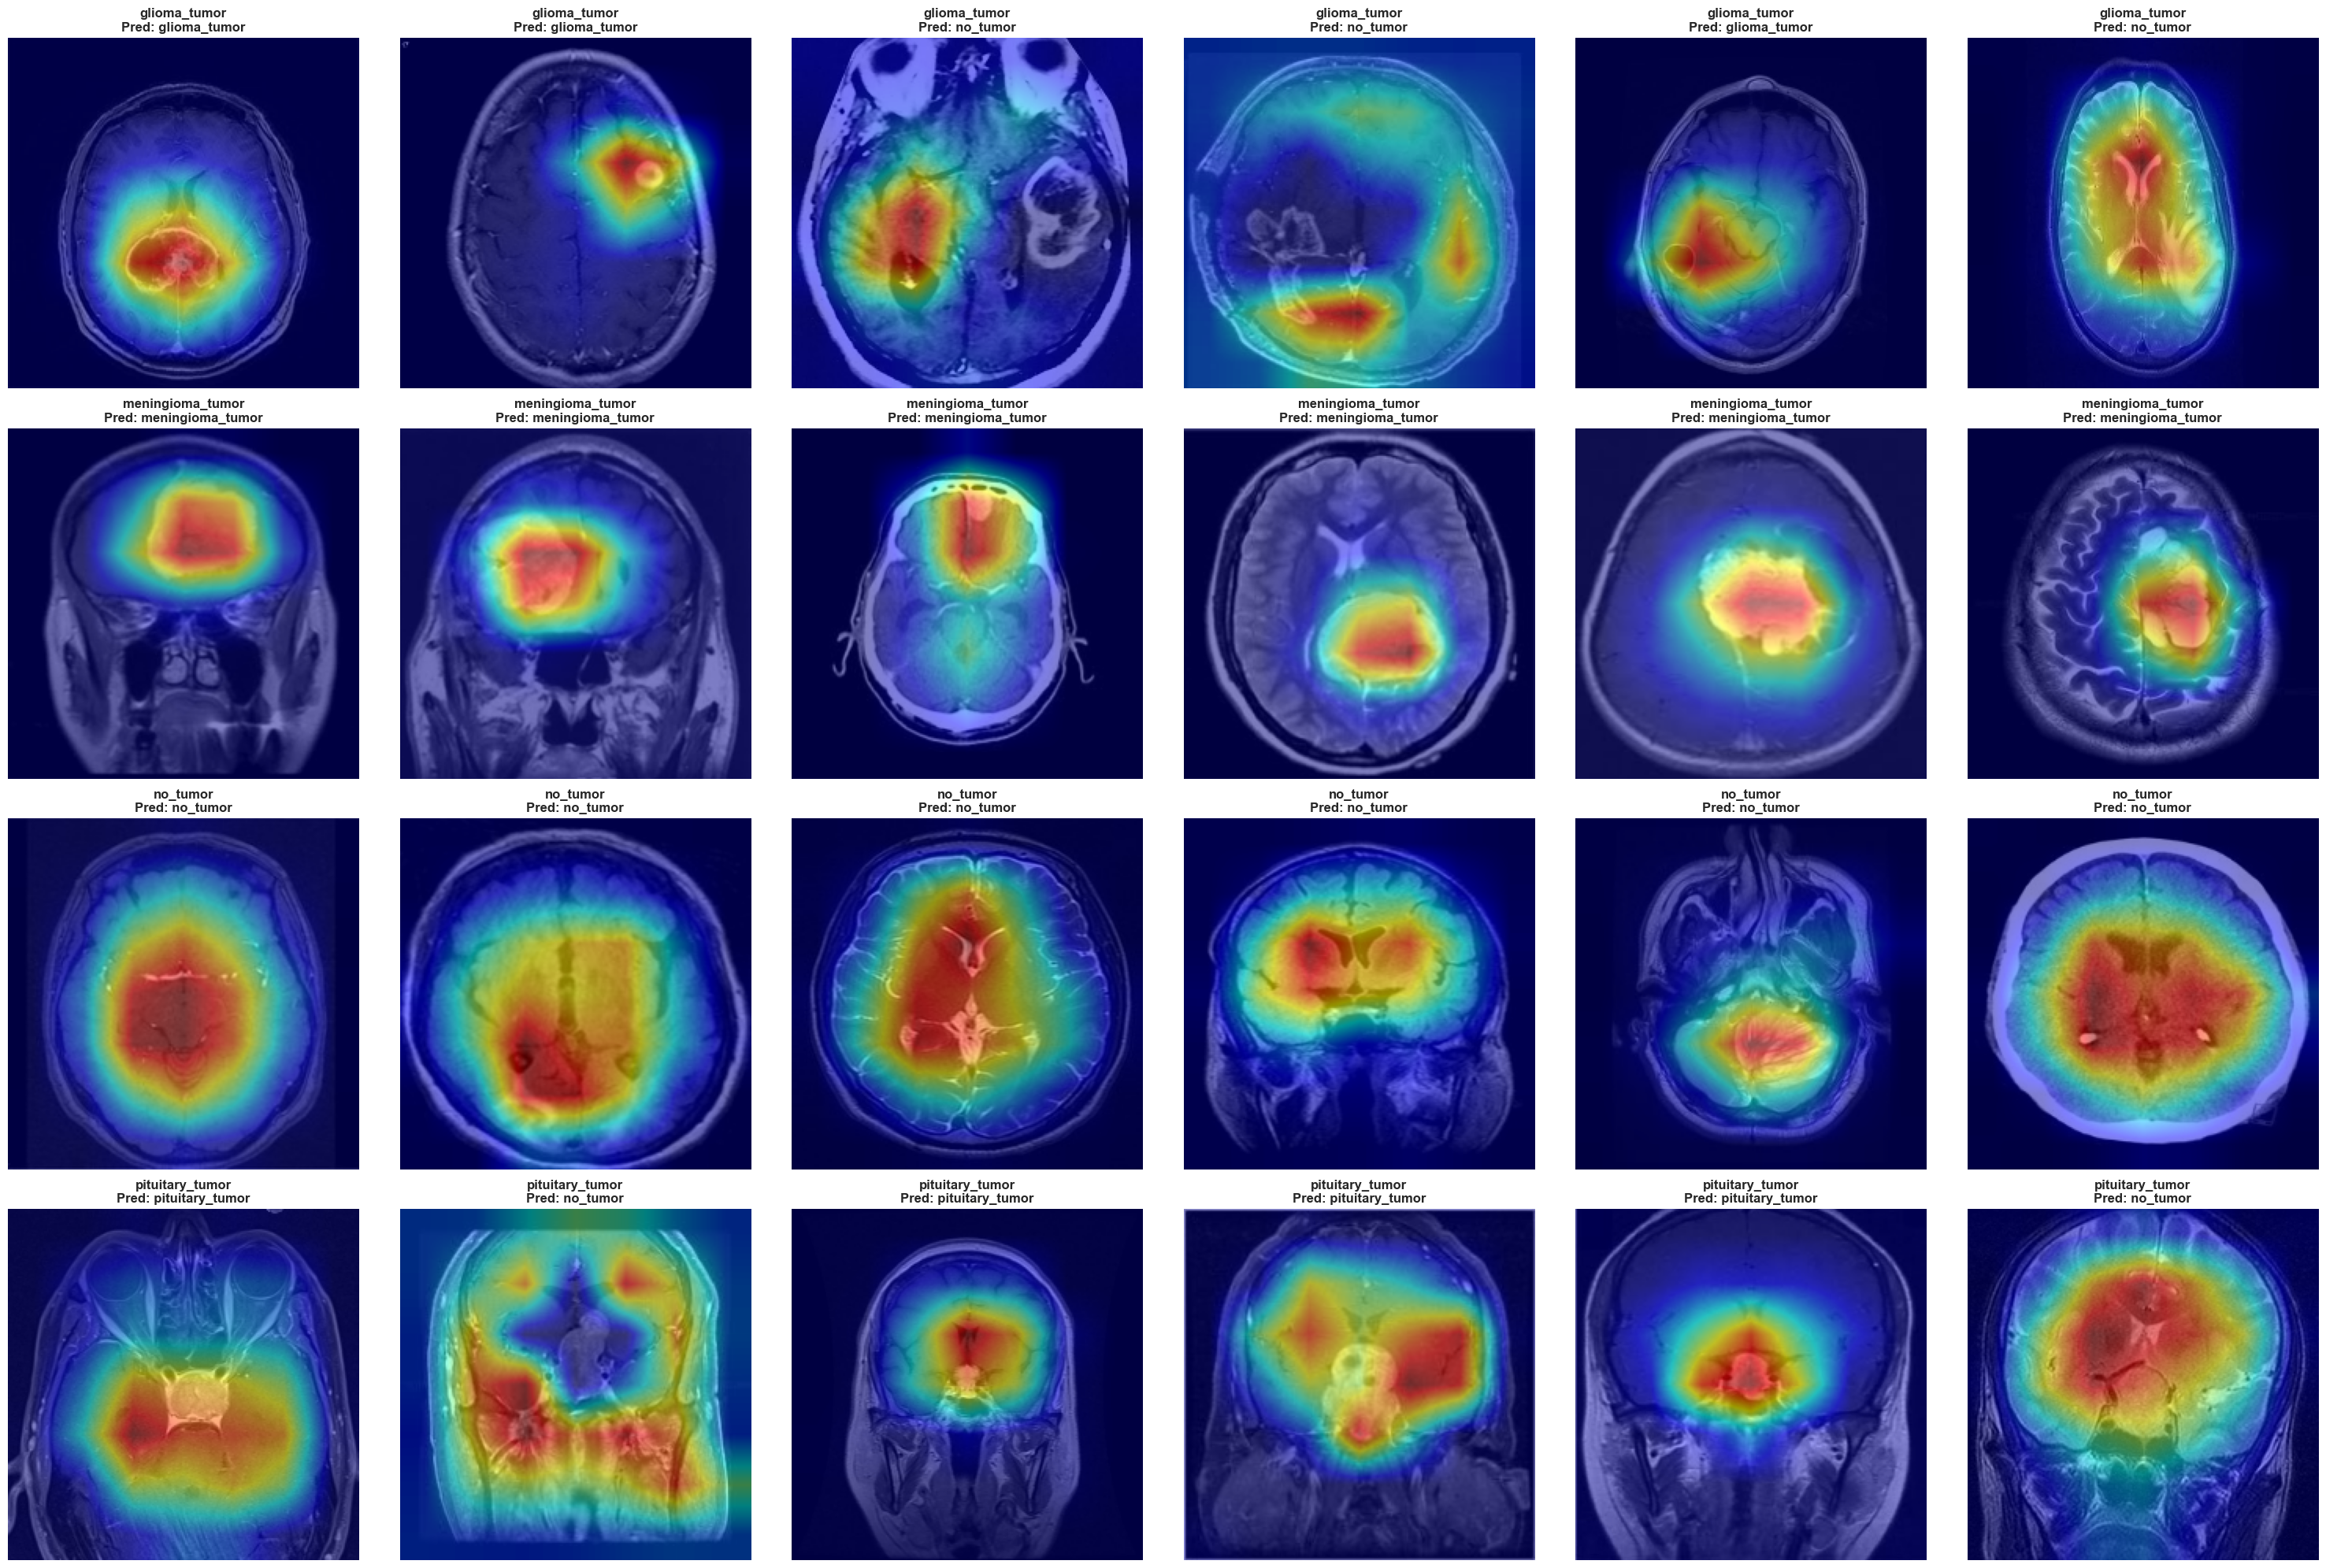

In [32]:
target_layers = [model.features[-1]]  
class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

visualize_gradcam_grid(
    model=model,
    dataset_root='../data/Testing/',
    class_names=class_names,
    target_layers=target_layers,
    device=device,
    samples_per_class=6
)
